   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('Advertising.csv')

In [ ]:
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])

print('=== 1. DATASET OVERVIEW ===')
print(df.head())

print('\n=== 2. DATA CLEANING & NULL CHECK ===')
print('Missing Values Count:')
print(df.isnull().sum())
print('\nDuplicates Count:', df.duplicated().sum())

print('\n=== 3. STATISTICAL SUMMARY ===')
print(df.describe())

=== 1. DATASET OVERVIEW ===
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

=== 2. DATA CLEANING & NULL CHECK ===
Missing Values Count:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicates Count: 0

=== 3. STATISTICAL SUMMARY ===
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


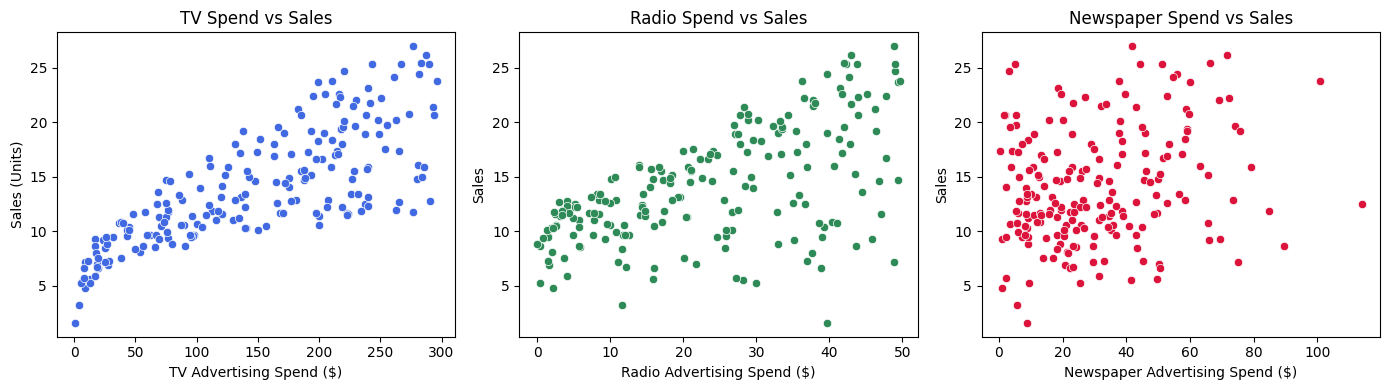

In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='TV', y='Sales', color='royalblue')
plt.title('TV Spend vs Sales')
plt.xlabel('TV Advertising Spend ($)')
plt.ylabel('Sales (Units)')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Radio', y='Sales', color='seagreen')
plt.title('Radio Spend vs Sales')
plt.xlabel('Radio Advertising Spend ($)')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Newspaper', y='Sales', color='crimson')
plt.title('Newspaper Spend vs Sales')
plt.xlabel('Newspaper Advertising Spend ($)')

plt.tight_layout()
plt.show()

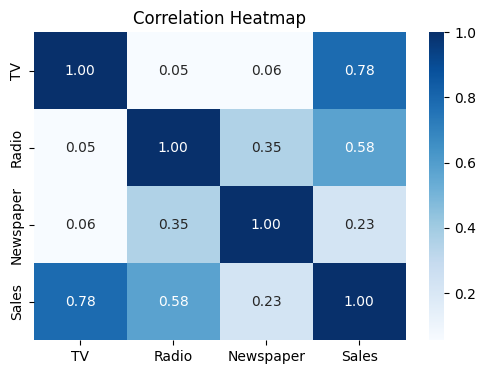

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Initialize & Train Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('\n=== 4. MODEL EVALUATION METRICS ===')
print(f'R² Score (Accuracy): {r2:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Coefficients Analysis (Business Insights)
coeff_df = pd.DataFrame(
    model.coef_, X.columns, columns=['Impact Coefficient']
)
coeff_df.loc['Intercept'] = model.intercept_
print('\n=== 5. MARKETING IMPACT COEFFICIENTS ===')
print(coeff_df)


=== 4. MODEL EVALUATION METRICS ===
R² Score (Accuracy): 0.8994
Mean Squared Error (MSE): 3.1741
Root Mean Squared Error (RMSE): 1.7816

=== 5. MARKETING IMPACT COEFFICIENTS ===
           Impact Coefficient
TV                   0.044730
Radio                0.189195
Newspaper            0.002761
Intercept            2.979067


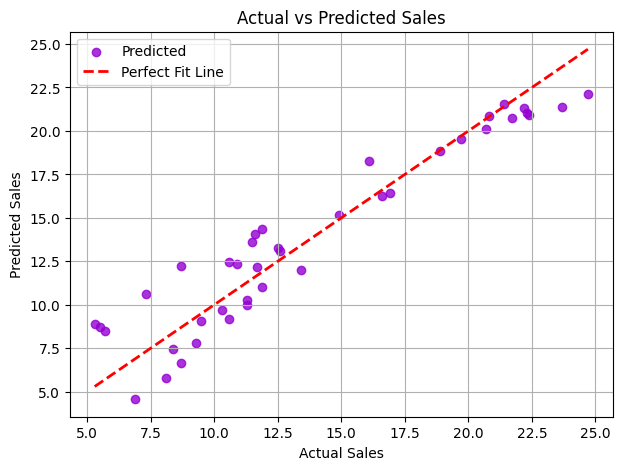

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='darkviolet', alpha=0.8, label='Predicted')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Fit Line',
)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sample_data = pd.DataFrame(
    [[230.1, 37.8, 69.2]], columns=['TV', 'Radio', 'Newspaper']
)
predicted_val = model.predict(sample_data)
print(
    f'\nSample Prediction [TV: $230.1, Radio: $37.8, Newspaper: $69.2] => Predicted Sales: {predicted_val[0]:.2f} units'
)


Sample Prediction [TV: $230.1, Radio: $37.8, Newspaper: $69.2] => Predicted Sales: 20.61 units
